# 1-Data Preparation and Cleaning

In [3]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, to_date, when, lit

spark = SparkSession.builder \
    .appName("FootballDataPreparation") \
    .getOrCreate()

In [4]:
# Data Loading
path_csv = "/workspace/data/rim_championnat_results_2007-2025.csv"
df_raw = spark.read.csv(path_csv, header=True, inferSchema=True)
df_raw.printSchema()
df_raw.show(5)

root
 |-- season: string (nullable = true)
 |-- date: string (nullable = true)
 |-- home_team: string (nullable = true)
 |-- away_team: string (nullable = true)
 |-- home_goals: integer (nullable = true)
 |-- away_goals: integer (nullable = true)

+--------------------+----------+---------------+-----------+----------+----------+
|              season|      date|      home_team|  away_team|home_goals|away_goals|
+--------------------+----------+---------------+-----------+----------+----------+
|Championnat D1 20...|02.08.2008|  ASAC Concorde|Nasr Sebkha|         2|         0|
|Championnat D1 20...|02.08.2008|         Police|   Tidjikja|         0|         1|
|Championnat D1 20...|01.08.2008|           Ksar|       SNIM|         1|         0|
|Championnat D1 20...|01.08.2008|Mauritel Mobile|      Armee|         0|         0|
|Championnat D1 20...|01.08.2008|  Tevragh-Zeina|  FC Trarza|         3|         0|
+--------------------+----------+---------------+-----------+----------+--------

In [5]:
# Type Conversion and Cleaning
df_cleaned = df_raw.withColumn("date", to_date(col("date"), "yyyy-MM-dd")) \
                   .withColumn("home_goals", col("home_goals").cast("int")) \
                   .withColumn("away_goals", col("away_goals").cast("int")) \
                   .dropna(subset=["home_goals", "away_goals", "home_team", "away_team"])

In [6]:
df_final = df_cleaned.withColumn("total_goals", col("home_goals") + col("away_goals")) \
                     .withColumn("goal_diff", col("home_goals") - col("away_goals")) \
                     .withColumn("result", 
                                 when(col("home_goals") > col("away_goals"), "Home Win")
                                 .when(col("home_goals") < col("away_goals"), "Away Win")
                                 .otherwise("Draw"))
df_final.show(10)

+--------------------+----+---------------+---------------+----------+----------+-----------+---------+--------+
|              season|date|      home_team|      away_team|home_goals|away_goals|total_goals|goal_diff|  result|
+--------------------+----+---------------+---------------+----------+----------+-----------+---------+--------+
|Championnat D1 20...|NULL|  ASAC Concorde|    Nasr Sebkha|         2|         0|          2|        2|Home Win|
|Championnat D1 20...|NULL|         Police|       Tidjikja|         0|         1|          1|       -1|Away Win|
|Championnat D1 20...|NULL|           Ksar|           SNIM|         1|         0|          1|        1|Home Win|
|Championnat D1 20...|NULL|Mauritel Mobile|          Armee|         0|         0|          0|        0|    Draw|
|Championnat D1 20...|NULL|  Tevragh-Zeina|      FC Trarza|         3|         0|          3|        3|Home Win|
|Championnat D1 20...|NULL|Garde Nationale|     Nouadhibou|         0|         0|          0|   

In [7]:
!find /workspace/ -name "rim_championnat_results_2007-2025.csv"

/workspace/data/rim_championnat_results_2007-2025.csv


In [ ]:
output_path = "/home/jovyan/work/data/prepared_results.parquet"
df_final.coalesce(1).write.mode("overwrite").parquet(output_path)

print(f"--- SUCCESS: Data written to {output_path} ---")

In [ ]:
!pip install selenium webdriver-manager

In [16]:
!ls -l /home/jovyan/work/data/prepared_results.parquet

total 16
-rw-r--r-- 1 jovyan users     0 Apr 12 23:52 _SUCCESS
-rw-r--r-- 1 jovyan users 12956 Apr 12 23:52 part-00000-2f633a78-863f-4103-8d95-f3db3b1ce242-c000.snappy.parquet


3.3 Real-Time Stream Simulation

In [24]:
pip install kafka-python pandas fastparquet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 135.1 kB/s eta 0:00:00a 0:00:03
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 181.9 kB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
df_test = pd.read_parquet('/home/jovyan/work/data/prepared_results.parquet/')
print(f"Nombre total de lignes dans le fichier : {len(df_test)}")
print(df_test['season'].value_counts())

Nombre total de lignes dans le fichier : 2744
season
Ligue 1 2024/2025           240
Super D1 2017/2018          182
Ligue 1 2023/2024           182
Ligue 1 2022/2023           182
Ligue 1 2021/2022           182
Ligue 1 2019/2020           182
Ligue 1 2018/2019           182
Championnat D1 2016/2017    182
Championnat D1 2014/2015    182
Championnat D1 2012/2013    182
Championnat D1 2011/2012    182
Championnat D1 2015/2016    156
Championnat D1 2009         132
Championnat D1 2010         132
Championnat D1 2007/2008    130
Championnat D1 2010/2011     72
Ligue 1 2020/2021            32
Championnat D1 2013/2014     30
Name: count, dtype: int64


# 2-Current Season Enrichment by Web Scraping

In [ ]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
from webdriver_manager.core.os_manager import ChromeType
import pandas as pd
import time
import os
import shutil

def scrape_matches():
    options = Options()
    options.add_argument("--headless=new")
    options.add_argument("--no-sandbox")
    options.add_argument("--disable-dev-shm-usage")

    browser_path = shutil.which("chromium-browser") or shutil.which("chromium") or shutil.which("google-chrome")
    if browser_path:
        options.binary_location = browser_path

    driver = webdriver.Chrome(
        service=Service(ChromeDriverManager(chrome_type=ChromeType.CHROMIUM).install()),
        options=options
    )

    url = "https://www.flashscore.com/football/mauritania/super-d1/results/"
    driver.get(url)
    time.sleep(8)

    matches = []
    rows = driver.find_elements(By.CSS_SELECTOR, "div.event__match")

    for row in rows:
        try:
            home = row.find_element(By.CSS_SELECTOR, ".event__homeParticipant").text
            away = row.find_element(By.CSS_SELECTOR, ".event__awayParticipant").text
            date_info = row.find_element(By.CSS_SELECTOR, ".event__time").text
            
            try:
                score_home = row.find_element(By.CSS_SELECTOR, ".event__score--home").text
                score_away = row.find_element(By.CSS_SELECTOR, ".event__score--away").text
            except:
                continue

            if score_home == "" or score_away == "":
                continue

            matches.append({
                'season': '2025/2026',
                'date': date_info.split(' ')[0],
                'home_team': home,
                'away_team': away,
                'home_goals': int(score_home),
                'away_goals': int(score_away)
            })
        except Exception:
            continue

    driver.quit()
    return matches

def main():
    FILE = "scraped_current_season.csv"
    
    data_list = scrape_matches()
    if not data_list:
        print("Aucune donnee extraite.")
        return

    new_df = pd.DataFrame(data_list)

    if os.path.exists(FILE):
        old_df = pd.read_csv(FILE)
        combined = pd.concat([old_df, new_df], ignore_index=True)
    else:
        combined = new_df

    combined = combined.drop_duplicates(subset=['date', 'home_team', 'away_team'], keep='last')
    
    combined.to_csv(FILE, index=False)

    print("-" * 30)
    print(f"Fichier : {FILE}")
    print(f"Total matchs : {len(combined)}")
    print("-" * 30)

main()

In [11]:
# Data Loading
path_csv = "/workspace/data/scraped_current_season.csv"
df_raw = spark.read.csv(path_csv, header=True, inferSchema=True)
df_raw.printSchema()
df_raw.show(5)

root
 |-- season: string (nullable = true)
 |-- date: string (nullable = true)
 |-- home_team: string (nullable = true)
 |-- away_team: string (nullable = true)
 |-- home_goals: integer (nullable = true)
 |-- away_goals: integer (nullable = true)
 |-- match_id: string (nullable = true)

+---------+----------+------------------+-----------------+----------+----------+--------------------+
|   season|      date|         home_team|        away_team|home_goals|away_goals|            match_id|
+---------+----------+------------------+-----------------+----------+----------+--------------------+
|2025-2026|2026-04-15|           Gendrim|    Tevragh-Zeina|         1|         1|2025-2026_2026-04...|
|2025-2026|2026-04-15|Nouakchott Academy|           Police|         0|         0|2025-2026_2026-04...|
|2025-2026|2026-04-15|            Chemal|           Douane|         1|         1|2025-2026_2026-04...|
|2025-2026|2026-04-15|             Kaedi|         Nzeidane|         2|         2|2025-2026_202

In [ ]:
from pyspark.sql.functions import col, to_date, when

input_path = "/workspace/data/scraped_current_season.csv"
df = spark.read.csv(input_path, header=True, inferSchema=True)

df_final = df.withColumn("date", to_date(col("date"), "yyyy-MM-dd")) \
             .withColumn("home_goals", col("home_goals").cast("int")) \
             .withColumn("away_goals", col("away_goals").cast("int")) \
             .dropna(subset=["home_goals", "away_goals"]) \
             .withColumn("total_goals", col("home_goals") + col("away_goals")) \
             .withColumn("result", when(col("home_goals") > col("away_goals"), "Home Win")
                                   .when(col("home_goals") < col("away_goals"), "Away Win")
                                   .otherwise("Draw"))

output_path = "/home/jovyan/work/data/scraped.parquet"
df_final.coalesce(1).write.mode("overwrite").parquet(output_path)

print("-" * 50)
print(f"SUCCESS: {input_path} converti en {output_path}")
print("-" * 50)
df_final.show(5)

In [12]:
import pandas as pd
df_test = pd.read_parquet('/home/jovyan/work/data/scraped.parquet')
print(f"Nombre total de lignes dans le fichier : {len(df_test)}")
print(df_test['season'].value_counts())

Nombre total de lignes dans le fichier : 102
season
2025-2026    102
Name: count, dtype: int64


In [ ]:
import os
from pyspark.sql import functions as F

path_scraped = "/home/jovyan/work/data/scraped.parquet"
path_prepared = "/home/jovyan/work/data/prepared_results.parquet/"
output_final = "/home/jovyan/work/data/final_mauritania_football_dataset.parquet"

if os.path.exists(path_scraped) and os.path.exists(path_prepared):
    df_scraped = spark.read.parquet(path_scraped)
    df_prepared = spark.read.parquet(path_prepared)
    
    common_cols = ["season", "date", "home_team", "away_team", "home_goals", "away_goals", "total_goals", "result"]
    
    df_final = df_prepared.select(*common_cols).unionByName(df_scraped.select(*common_cols))
    
    df_final.coalesce(1).write.mode("overwrite").parquet(output_final)
    
    print(f"NOMBRE TOTAL DE LIGNES : {df_final.count()}")
    df_final.groupBy("season").count().sort(F.desc("season")).show(10)

else:
    print("Erreur : Fichiers sources introuvables.")

In [17]:
import pandas as pd
df_test = pd.read_parquet('/home/jovyan/work/data/final_mauritania_football_dataset.parquet/')
print(f"Nombre total de lignes dans le fichier : {len(df_test)}")
print(df_test['season'].value_counts())

Nombre total de lignes dans le fichier : 2846
season
Ligue 1 2024/2025           240
Championnat D1 2016/2017    182
Ligue 1 2021/2022           182
Championnat D1 2011/2012    182
Championnat D1 2012/2013    182
Ligue 1 2023/2024           182
Championnat D1 2014/2015    182
Super D1 2017/2018          182
Ligue 1 2018/2019           182
Ligue 1 2019/2020           182
Ligue 1 2022/2023           182
Championnat D1 2015/2016    156
Championnat D1 2010         132
Championnat D1 2009         132
Championnat D1 2007/2008    130
2025-2026                   102
Championnat D1 2010/2011     72
Ligue 1 2020/2021            32
Championnat D1 2013/2014     30
Name: count, dtype: int64


# 3-Real-Time Stream Simulation

To configure the message sending logic and the publishing frequency to Kafka, please refer to the detailed script in: src/producer.py

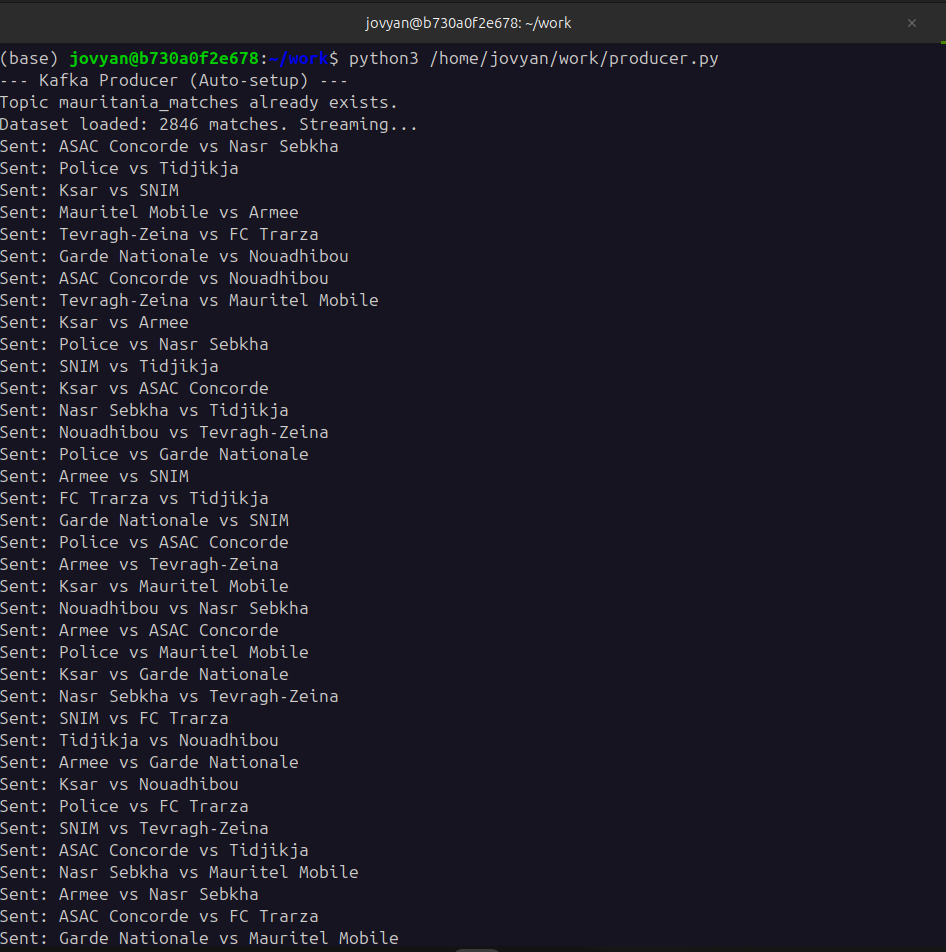

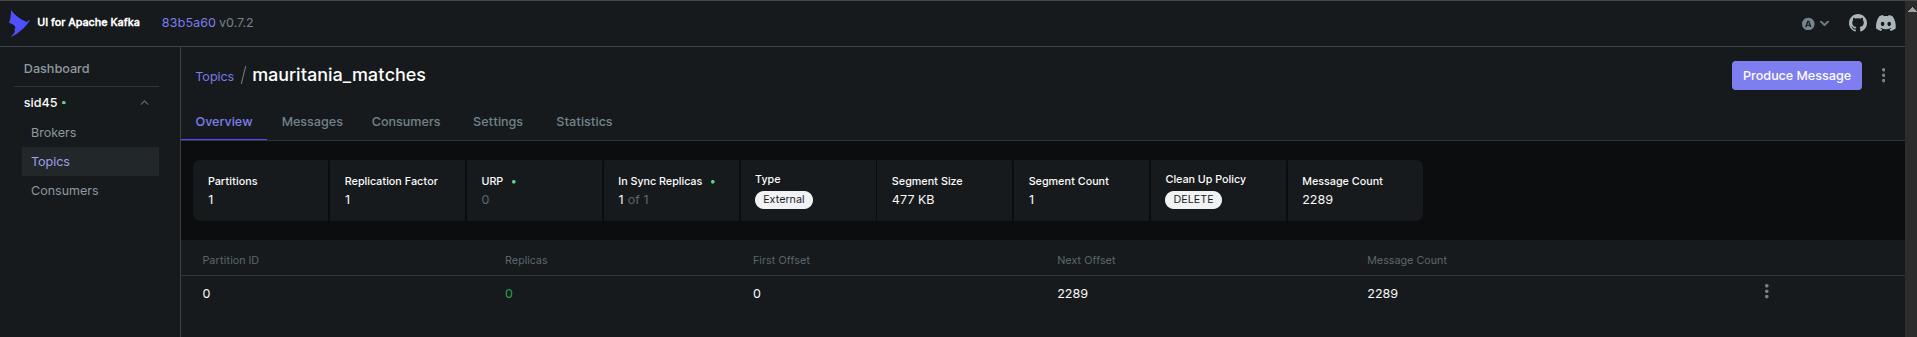

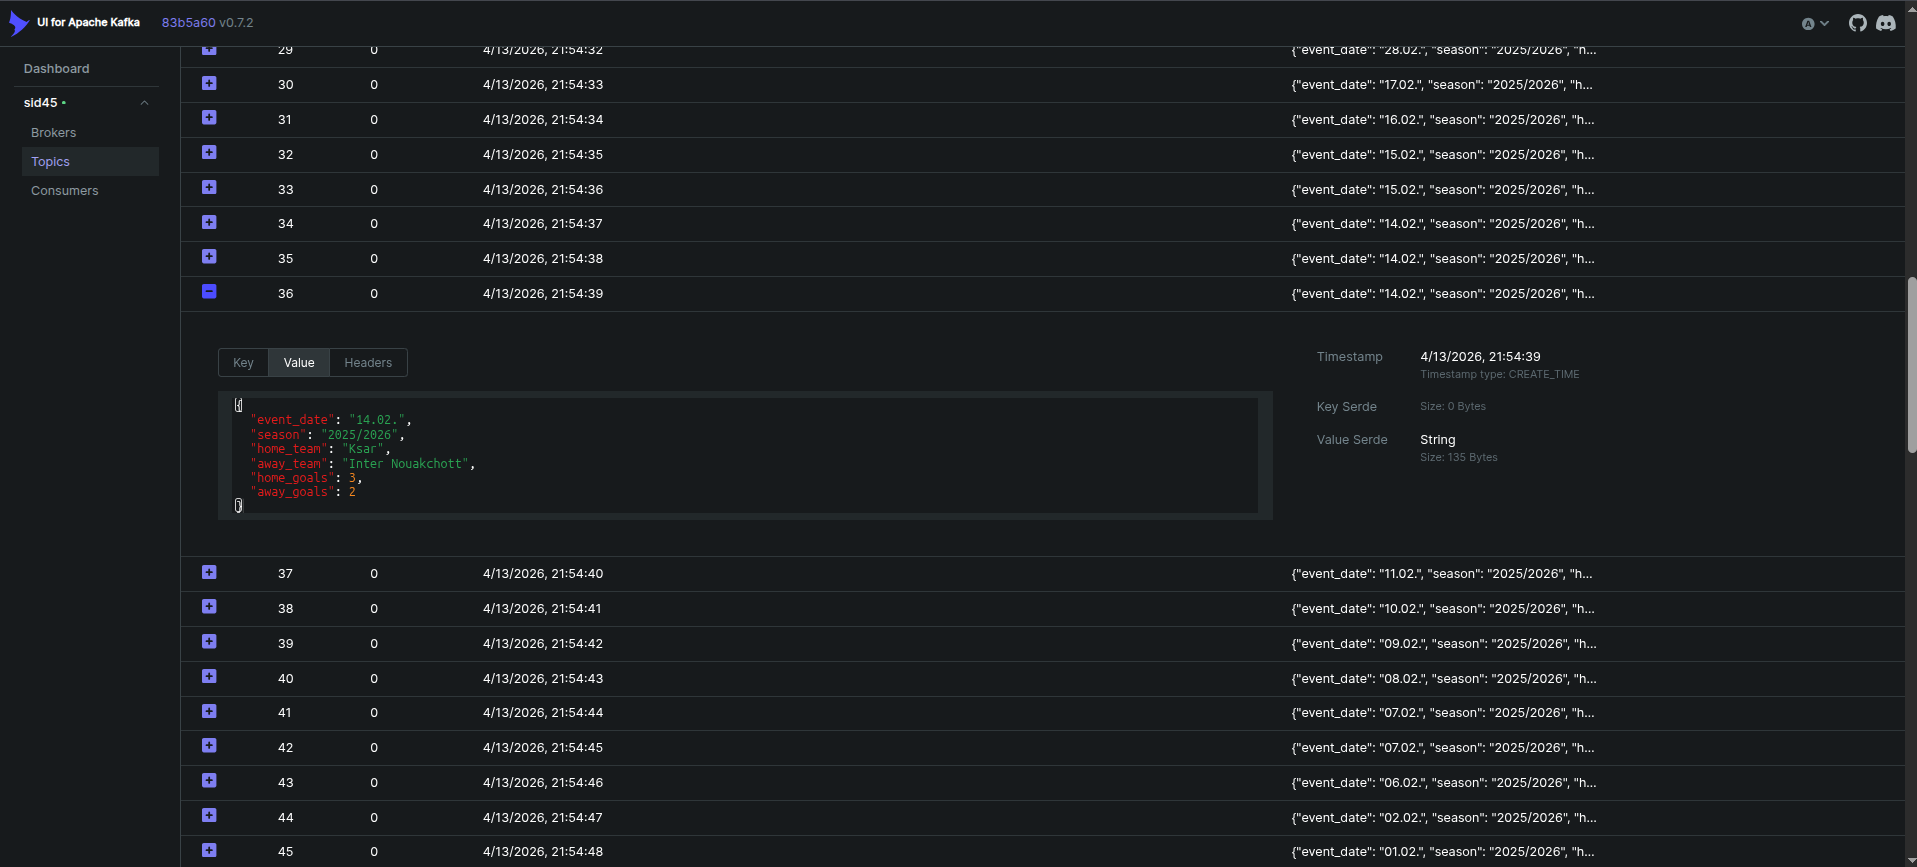

# 4-Streaming Processing with Spark

Full details on the Spark Streaming configuration—specifically watermark management, windowing, and writing to Parquet format—can be found in: src/stream_job.py

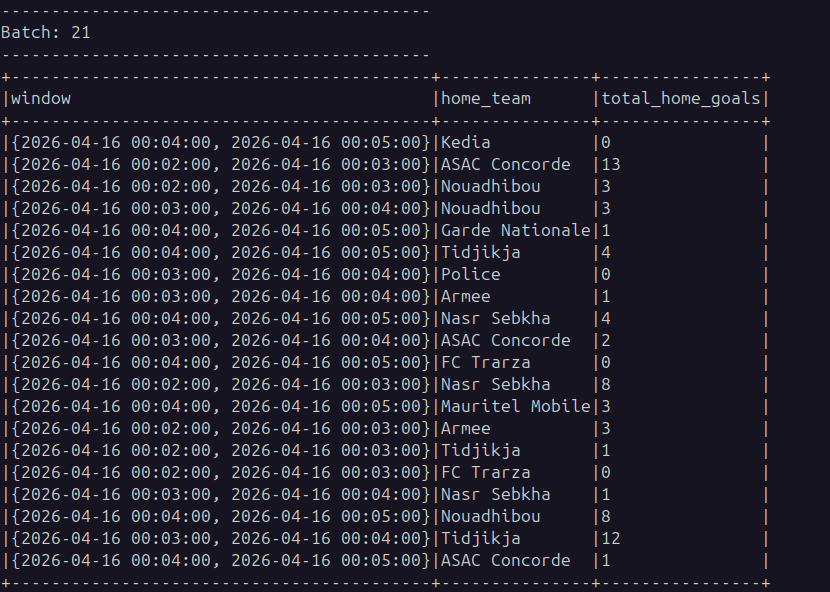

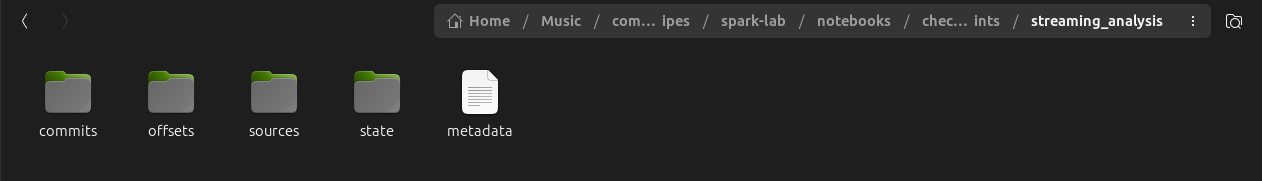

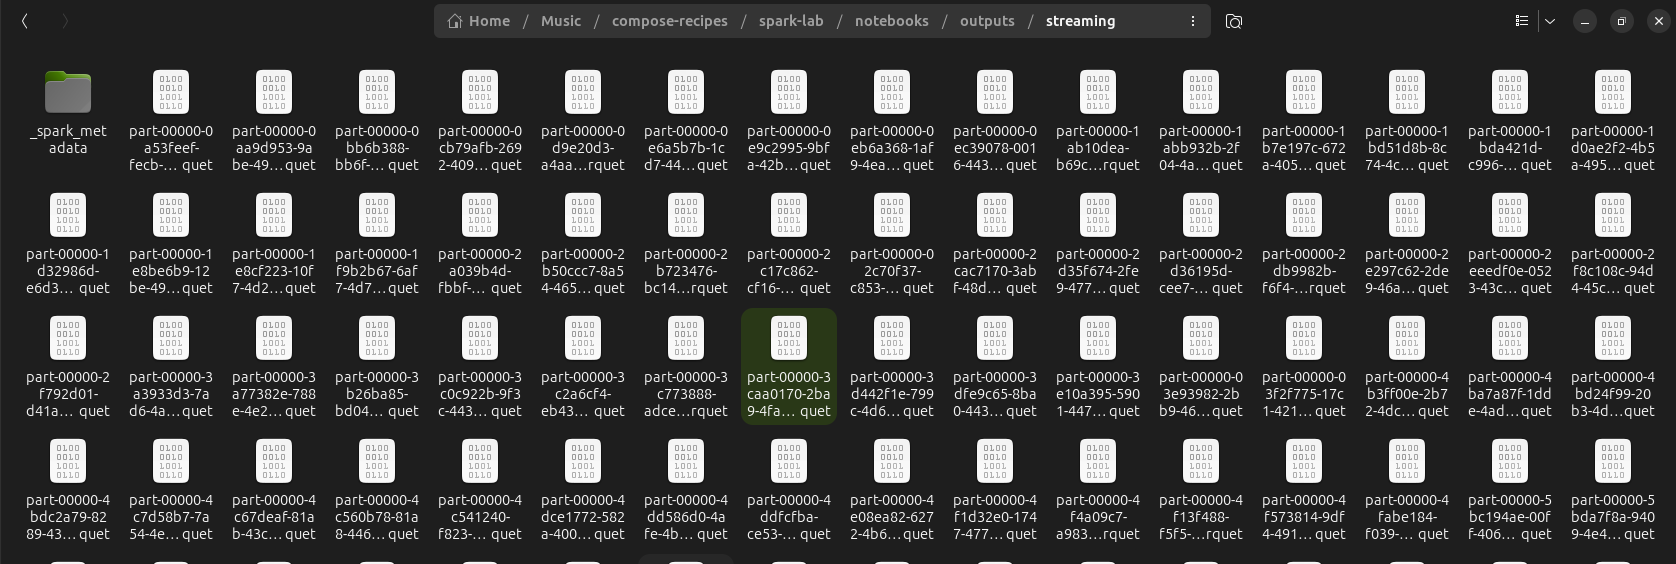